In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(8, 8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [20]:
# 设置参数
def order_points(pts):
	# 一共4个坐标点
	rect = np.zeros((4, 2), dtype = "float32")
	# 按顺序找到对应坐标0123分别是 左上，右上，右下，左下
	# 计算左上，右下
	s = pts.sum(axis = 1)
	rect[0] = pts[np.argmin(s)]
	rect[2] = pts[np.argmax(s)]
	# 计算右上和左下
	diff = np.diff(pts, axis = 1)
	rect[1] = pts[np.argmin(diff)]
	rect[3] = pts[np.argmax(diff)]
	return rect
def four_point_transform(image, pts):
    # 获取透视变换矩阵
    rect = order_points(pts)
    (tl, tr, br, bl) = rect
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = max(int(widthA), int(widthB))
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = max(int(heightA), int(heightB))

    # 透视变换矩阵
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    return warped
# def four_point_transform(image, pts):
# 	# 获取输入坐标点
# 	rect = order_points(pts)
# 	(tl, tr, br, bl) = rect
# 	# 计算输入的w和h值
# 	widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
# 	widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
# 	maxWidth = max(int(widthA), int(widthB))
# 	heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
# 	heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
# 	maxHeight = max(int(heightA), int(heightB))
# 	# 变换后对应坐标位置
# 	dst = np.array([
# 		[0, 0],
# 		[maxWidth - 1, 0],
# 		[maxWidth - 1, maxHeight - 1],
# 		[0, maxHeight - 1]], dtype = "float32")
# 	# 计算变换矩阵
# 	M = cv2.getPerspectiveTransform(rect, dst)
# 	warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
# 	# 返回变换后结果
# 	return warped
def resize(image, width=None, height=None, inter=cv2.INTER_AREA):
	dim = None
	(h, w) = image.shape[:2]
	if width is None and height is None:
		return image
	if width is None:
		r = height / float(h)
		dim = (int(w * r), height)
	else:
		r = width / float(w)
		dim = (width, int(h * r))
	resized = cv2.resize(image, dim, interpolation=inter)
	return resized

## 文档扫描OCR识别

STEP 1: 边缘检测


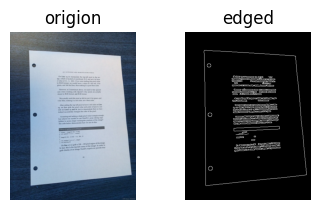

STEP 2: 获取轮廓


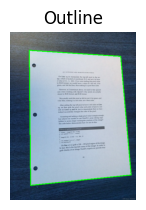

STEP 3: 变换


(<Axes: title={'center': 'Scanned'}>,
 Text(0.5, 1.0, 'Scanned'),
 (-0.5, 1961.5, 2623.5, -0.5))

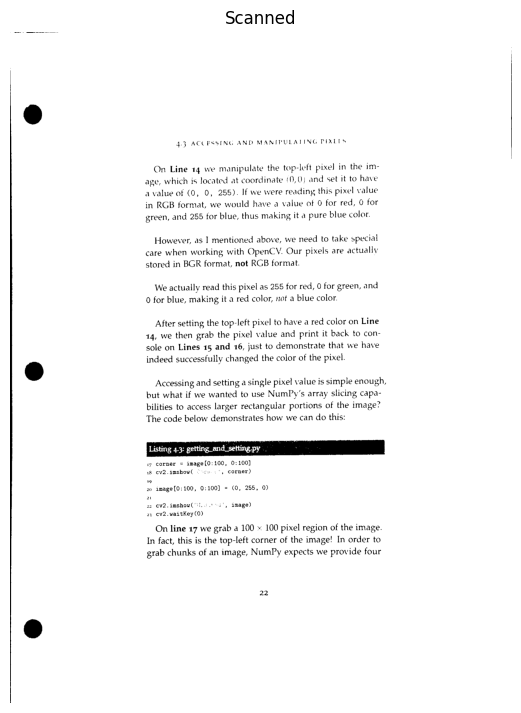

In [27]:
# 读取输入
image = cv2.imread('./assets/doc2.jpeg')
#坐标也会相同变化
ratio = image.shape[0] / 500.0
orig = image.copy()
image = resize(orig, height = 500)
# 预处理
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)
edged = cv2.Canny(gray, 50, 150)
# 展示预处理结果
print("STEP 1: 边缘检测")
plt.subplot(231), plt.imshow(image), plt.title("origion"), plt.axis('off')
plt.subplot(232), plt.imshow(edged, 'gray'), plt.title("edged"), plt.axis('off')
plt.show()

# 轮廓检测
cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
cnts = sorted(cnts, key = cv2.contourArea, reverse = True)[:5]
# 遍历轮廓
for c in cnts:
	# 计算轮廓近似
	peri = cv2.arcLength(c, True)
	# C表示输入的点集
	# epsilon表示从原始轮廓到近似轮廓的最大距离，它是一个准确度参数
	# True表示封闭的
	approx = cv2.approxPolyDP(c, 0.01 * peri, True)
	# 4个点的时候就拿出来
	if len(approx) == 4:
		screenCnt = approx
		break
# 展示结果
print("STEP 2: 获取轮廓")
cv2.drawContours(image, [screenCnt], -1, (0, 255, 0), 2)
plt.subplot(231), plt.imshow(image), plt.title("Outline"), plt.axis('off')
plt.show()

# 透视变换
warped = four_point_transform(orig, screenCnt.reshape(4, 2) * ratio)
# 二值处理
warped = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
ref = cv2.threshold(warped, 120, 255, cv2.THRESH_BINARY)[1]
cv2.imwrite('./assets/scan.jpg', ref)
# 展示结果
print("STEP 3: 变换")
plt.figure(figsize=(22, 22))
plt.subplot(232), plt.imshow(ref, 'gray'), plt.title("Scanned"), plt.axis('off')